# 03 — Age/sex/time-specific rates for self-report-only conditions

For the three conditions in `MCQ` that have a self-report item but no NHANES biomarker — **heart failure, AMI, stroke** — we estimate weighted prevalence by age band × sex × cycle. (Revascularization is also self-report-only in principle, but NHANES does not ask about it, so it cannot be tabulated here.)

**Cohort:** Adults ≥20, NHANES continuous 1999–2018 (10 two-year cycles). For each cycle we use `WTMEC2YR` (or `WTMEC4YR` for 1999-2000, which is proportional within the cycle and so gives the same proportion estimate). SE via paired-PSU jackknife on `SDMVPSU × SDMVSTRA`.

**Variables:**
- `MCQ160B` → ever told congestive heart failure
- `MCQ160E` → ever told heart attack / MI
- `MCQ160F` → ever told stroke

We bin age in 10-year bands and pool 2-cycle pairs (so 5 four-year bins for plotting) to stabilize cell estimates.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path(os.path.abspath(os.path.join('..', 'data')))
DERIVED = DATA / 'derived'
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)

df = pd.read_parquet(DERIVED / 'sr_trend_1999_2018.parquet')
print(f'{len(df):,} adults across {df.CYCLE.nunique()} cycles')

52,398 adults across 10 cycles


## Setup: age bands, time bins, jackknife helper

In [2]:
AGE_BANDS = [(20, 40), (40, 55), (55, 70), (70, 200)]
AGE_LABELS = ['20–39', '40–54', '55–69', '70+']
df['AGE_BAND'] = pd.cut(df['AGE'],
                        [b[0] for b in AGE_BANDS] + [AGE_BANDS[-1][1]],
                        labels=AGE_LABELS, right=False)

TIME_BINS = {
    '1999–2002': ['1999-2000', '2001-2002'],
    '2003–2006': ['2003-2004', '2005-2006'],
    '2007–2010': ['2007-2008', '2009-2010'],
    '2011–2014': ['2011-2012', '2013-2014'],
    '2015–2018': ['2015-2016', '2017-2018'],
}
TIME_MID = {'1999–2002': 2000.5, '2003–2006': 2004.5, '2007–2010': 2008.5,
            '2011–2014': 2012.5, '2015–2018': 2016.5}

def time_bin(cycle):
    for label, cycles in TIME_BINS.items():
        if cycle in cycles:
            return label
    return None

df['TIME_BIN'] = df['CYCLE'].map(time_bin)


def w_prop(v, w):
    m = ~np.isnan(v) & (w > 0)
    if m.sum() == 0:
        return np.nan
    return float(np.average(v[m], weights=w[m]))


def paired_jk(sub, var):
    sub = sub.dropna(subset=[var, 'weight', 'SDMVPSU', 'SDMVSTRA'])
    sub = sub[sub['weight'] > 0]
    if len(sub) < 30:
        return np.nan, np.nan, len(sub)
    v = sub[var].values.astype(float)
    w = sub['weight'].values.astype(float)
    s = sub['SDMVSTRA'].astype(int).values
    p = sub['SDMVPSU'].astype(int).values
    theta = w_prop(v, w)
    var_sum = 0.0
    for st in np.unique(s):
        in_st = (s == st)
        psus = np.unique(p[in_st])
        if len(psus) < 2:
            continue
        for pu in psus:
            wr = w.copy()
            mask_in = in_st & (p == pu)
            mask_other = in_st & (p != pu)
            wr[mask_in] = 0.0
            wr[mask_other] = wr[mask_other] * 2.0
            theta_r = w_prop(v, wr)
            if not np.isnan(theta_r):
                var_sum += (theta_r - theta) ** 2
    return theta, np.sqrt(var_sum), len(sub)


def cell_table(var, by_age, by_sex, by_time):
    keys = []
    if by_age:  keys.append('AGE_BAND')
    if by_sex:  keys.append('SEX')
    if by_time: keys.append('TIME_BIN')
    rows = []
    for grp, sub in df.groupby(keys, observed=True):
        theta, se, n = paired_jk(sub.copy(), var)
        row = {k: g for k, g in zip(keys, grp if isinstance(grp, tuple) else (grp,))}
        row.update({
            'n': n,
            'pct': 100 * theta if theta == theta else np.nan,
            'se':  100 * se if se == se else np.nan,
            'lo':  100 * (theta - 1.96 * se),
            'hi':  100 * (theta + 1.96 * se),
        })
        rows.append(row)
    return pd.DataFrame(rows)

## Overall trends — sex-pooled, age-pooled, by time bin

    condition  time_bin    mid     n  pct   se   lo   hi
       Stroke 1999–2002 2000.5  9462 2.29 0.28 1.74 2.84
       Stroke 2003–2006 2004.5  9502 2.85 0.34 2.19 3.51
       Stroke 2007–2010 2008.5 11742 2.89 0.31 2.27 3.50
       Stroke 2011–2014 2012.5 10898 2.91 0.26 2.40 3.41
       Stroke 2015–2018 2016.5 10725 3.02 0.28 2.47 3.56
          AMI 1999–2002 2000.5  9450 3.17 0.35 2.49 3.85
          AMI 2003–2006 2004.5  9498 3.81 0.44 2.94 4.67
          AMI 2007–2010 2008.5 11741 3.23 0.31 2.62 3.84
          AMI 2011–2014 2012.5 10898 3.26 0.32 2.64 3.89
          AMI 2015–2018 2016.5 10722 3.52 0.41 2.73 4.32
Heart failure 1999–2002 2000.5  9430 2.10 0.28 1.55 2.65
Heart failure 2003–2006 2004.5  9479 2.57 0.27 2.05 3.09
Heart failure 2007–2010 2008.5 11724 2.18 0.28 1.64 2.72
Heart failure 2011–2014 2012.5 10885 2.68 0.33 2.03 3.33
Heart failure 2015–2018 2016.5 10713 2.37 0.26 1.86 2.89


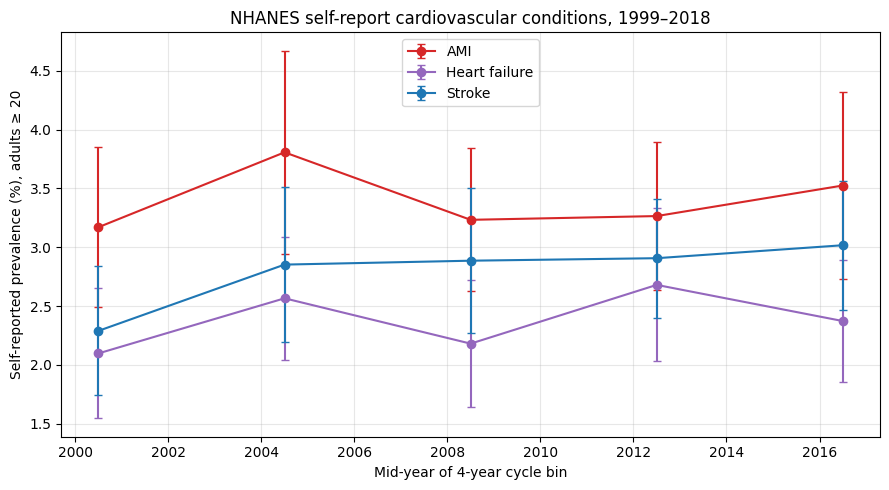

In [3]:
overall_rows = []
for var, name in [('STROKE_SELF', 'Stroke'),
                  ('AMI_SELF',    'AMI'),
                  ('HF_SELF',     'Heart failure')]:
    for tb, cycles in TIME_BINS.items():
        sub = df[df['CYCLE'].isin(cycles)]
        theta, se, n = paired_jk(sub.copy(), var)
        overall_rows.append({
            'condition': name, 'time_bin': tb, 'mid': TIME_MID[tb],
            'n': n, 'pct': 100 * theta, 'se': 100 * se,
            'lo': 100 * (theta - 1.96 * se),
            'hi': 100 * (theta + 1.96 * se),
        })
overall = pd.DataFrame(overall_rows)
print(overall.round(2).to_string(index=False))

# Plot — overall trend with CIs
fig, ax = plt.subplots(figsize=(9, 5))
colors = {'Stroke': 'tab:blue', 'AMI': 'tab:red', 'Heart failure': 'tab:purple'}
for name, sub in overall.groupby('condition'):
    sub = sub.sort_values('mid')
    yerr = [sub['pct'] - sub['lo'], sub['hi'] - sub['pct']]
    ax.errorbar(sub['mid'], sub['pct'], yerr=yerr, fmt='o-',
                capsize=3, color=colors[name], label=name)
ax.set_xlabel('Mid-year of 4-year cycle bin')
ax.set_ylabel('Self-reported prevalence (%), adults ≥ 20')
ax.set_title('NHANES self-report cardiovascular conditions, 1999–2018')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## By age band — sex-pooled, time-pooled

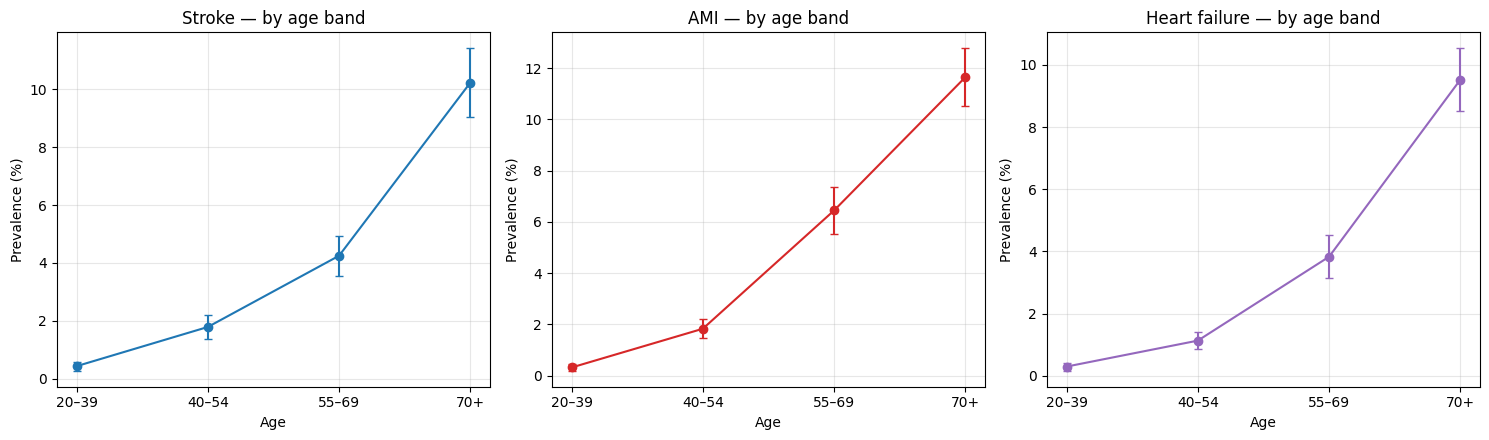

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
for ax, (var, name) in zip(axes, [('STROKE_SELF', 'Stroke'),
                                   ('AMI_SELF',    'AMI'),
                                   ('HF_SELF',     'Heart failure')]):
    t = cell_table(var, by_age=True, by_sex=False, by_time=False)
    t = t.sort_values('AGE_BAND')
    yerr = [t['pct'] - t['lo'], t['hi'] - t['pct']]
    ax.errorbar(t['AGE_BAND'], t['pct'], yerr=yerr, fmt='o-',
                capsize=3, color=colors[name])
    ax.set_title(f'{name} — by age band')
    ax.set_xlabel('Age')
    ax.set_ylabel('Prevalence (%)')
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## By age × sex × time — heart attack

One panel per age band; lines = sex; x = time bin midpoint; error bars = 95 % CI from paired-PSU jackknife.

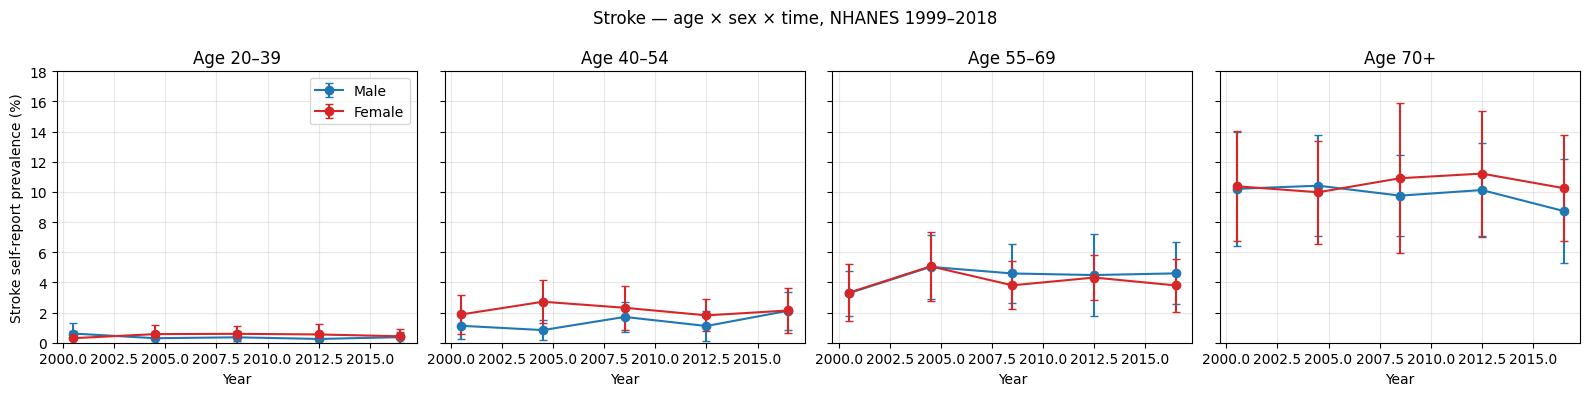

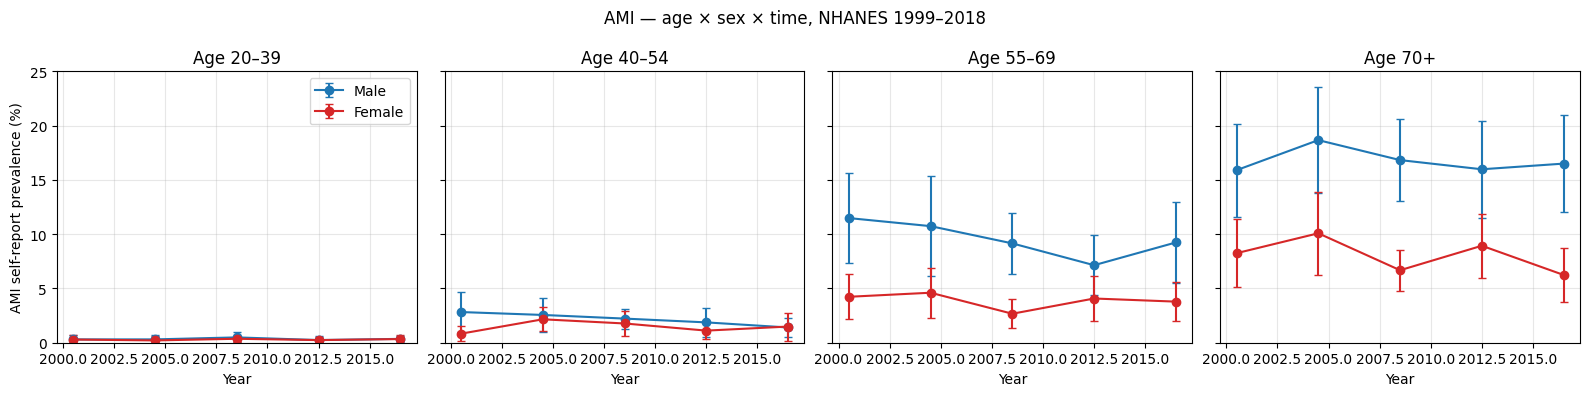

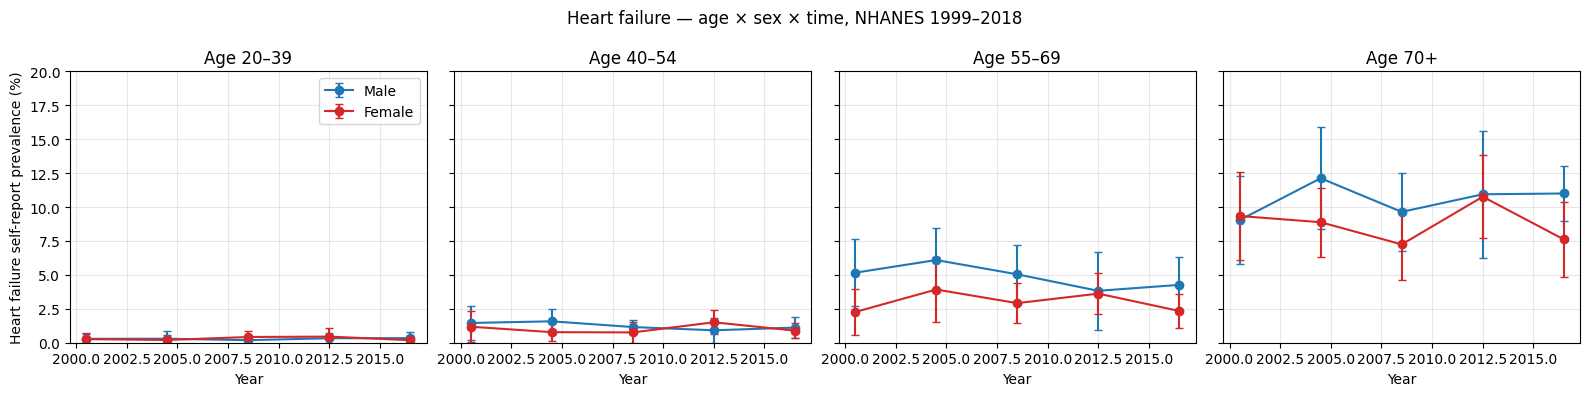

In [5]:
def plot_age_sex_time(var, name, ymax=None):
    t = cell_table(var, by_age=True, by_sex=True, by_time=True)
    t['mid'] = t['TIME_BIN'].map(TIME_MID)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    for ax, age in zip(axes, AGE_LABELS):
        sub = t[t['AGE_BAND'] == age]
        for sex, color in [('Male', 'tab:blue'), ('Female', 'tab:red')]:
            ss = sub[sub['SEX'] == sex].sort_values('mid')
            yerr = [ss['pct'] - ss['lo'], ss['hi'] - ss['pct']]
            ax.errorbar(ss['mid'], ss['pct'], yerr=yerr,
                        fmt='o-', capsize=3, color=color, label=sex)
        ax.set_title(f'Age {age}')
        ax.set_xlabel('Year')
        ax.grid(alpha=0.3)
        if ymax: ax.set_ylim(0, ymax)
    axes[0].set_ylabel(f'{name} self-report prevalence (%)')
    axes[0].legend()
    fig.suptitle(f'{name} — age × sex × time, NHANES 1999–2018')
    plt.tight_layout(); plt.show()
    return t

stroke = plot_age_sex_time('STROKE_SELF', 'Stroke', ymax=18)
ami    = plot_age_sex_time('AMI_SELF',    'AMI',    ymax=25)
hf     = plot_age_sex_time('HF_SELF',     'Heart failure', ymax=20)

## Tables for downstream use

Per-cell point estimates + CIs for each of the three outcomes.

In [6]:
print('Heart-attack (AMI) prevalence by age × sex × time:')
ami_table = ami.pivot_table(index=['AGE_BAND', 'SEX'], columns='TIME_BIN',
                             values='pct', observed=True).round(2)
print(ami_table.to_string())

print('\nStroke prevalence by age × sex × time:')
stroke_table = stroke.pivot_table(index=['AGE_BAND', 'SEX'], columns='TIME_BIN',
                                   values='pct', observed=True).round(2)
print(stroke_table.to_string())

print('\nHeart-failure prevalence by age × sex × time:')
hf_table = hf.pivot_table(index=['AGE_BAND', 'SEX'], columns='TIME_BIN',
                          values='pct', observed=True).round(2)
print(hf_table.to_string())

Heart-attack (AMI) prevalence by age × sex × time:
TIME_BIN         1999–2002  2003–2006  2007–2010  2011–2014  2015–2018
AGE_BAND SEX                                                          
20–39    Female       0.29       0.21       0.36       0.24       0.34
         Male         0.31       0.31       0.49       0.25       0.36
40–54    Female       0.83       2.16       1.77       1.12       1.49
         Male         2.83       2.56       2.22       1.87       1.40
55–69    Female       4.23       4.61       2.67       4.07       3.79
         Male        11.48      10.74       9.15       7.14       9.24
70+      Female       8.25      10.08       6.68       8.93       6.24
         Male        15.89      18.66      16.82      15.98      16.50

Stroke prevalence by age × sex × time:
TIME_BIN         1999–2002  2003–2006  2007–2010  2011–2014  2015–2018
AGE_BAND SEX                                                          
20–39    Female       0.30       0.57       0.59       0.